In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/featured_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

df["DateOrdinal"] = df["Date"].map(pd.Timestamp.toordinal)

df = df.sort_values("Date")

In [3]:
drop_cols = [
    "Sales",
    "SalesPerCustomer",
    "StoreAverageSales"
]

drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols + ["Date"])

y = df["Sales"]

In [4]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [5]:
categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_cols = X_train.select_dtypes(
    include=np.number
).columns.tolist()

In [6]:
categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_cols = X_train.select_dtypes(
    include=np.number
).columns.tolist()

In [7]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [8]:
xgb = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

**Build Pipeline**

In [9]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb)
])

**Define Hyperparameter Search Space**

In [10]:
param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [4, 6, 8, 10],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

Randomized Search

In [11]:
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['Store',
                                                                                'DayOfWeek',
                                                                                'Customers',
                                                                                'Open',
                                                                                'Promo',
                                                                                'SchoolHoliday',
                                                                                'CompetitionDistance',
                                                                                'CompetitionOpenSinceMonth',
                                                                                'CompetitionOpenSinceYear',
                                                                                'Promo2',
                                                                                'Promo2SinceWeek',
                                                                                'Promo2SinceYe...
                                                           multi_strategy=None,
                                                           n_estimators=None,
                                                           n_jobs=None,
                                                           num_parallel_tree=None, ...))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.8, 1.0],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1],
                                        'model__max_depth': [4, 6, 8, 10],
                                        'model__n_estimators': [200, 300, 500],
                                        'model__subsample': [0.8, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [12]:
print(search.best_params_)

{'model__subsample': 1.0, 'model__n_estimators': 300, 'model__max_depth': 10, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}


**Best Model**

In [13]:
best_model = search.best_estimator_

**Predictions**

In [14]:
predictions = best_model.predict(X_test)

In [15]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 269.6433410644531
RMSE: 418.9456818908628
R2  : 0.9882491827011108


**Feature Importance**

Because we're using a preprocessing pipeline, getting feature names requires a couple of extra steps.

In [16]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

importances = best_model.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

importance_df.head(20)

,Feature,Importance
3,num__Open,0.463581
2,num__Customers,0.169511
36,cat__StateHoliday_0,0.079494
45,cat__Assortment_b,0.074127
24,num__Sales_Lag_14,0.042767
41,cat__StoreType_b,0.031784
4,num__Promo,0.027351
43,cat__StoreType_d,0.026915
22,num__Sales_Lag_1,0.014398
1,num__DayOfWeek,0.008781


**Plot Top Features**

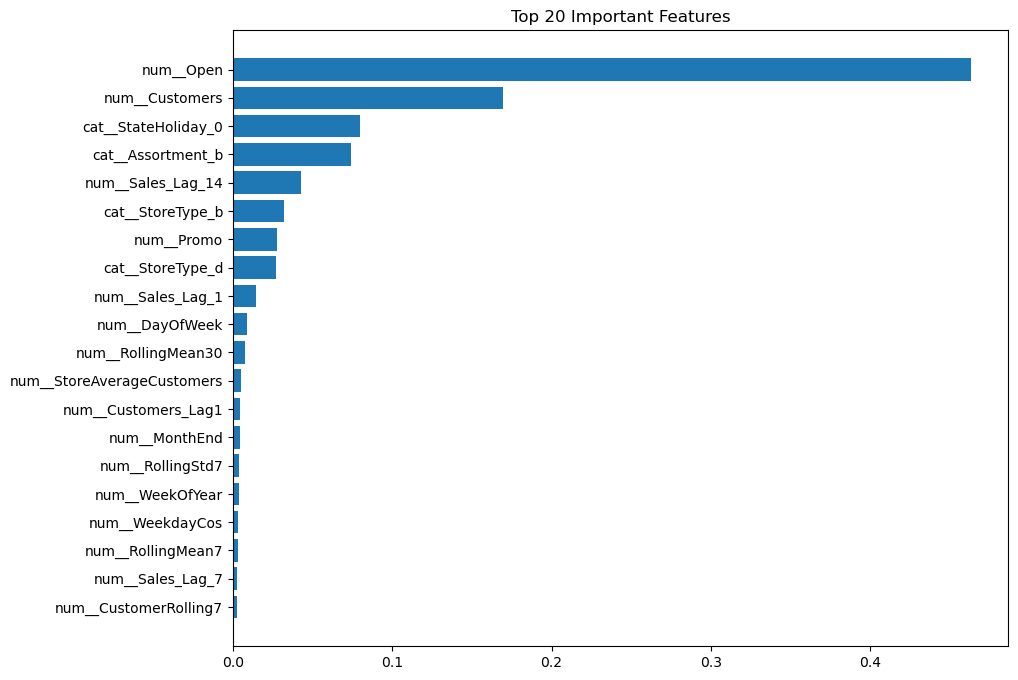

In [17]:
top20 = importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(top20["Feature"], top20["Importance"])

plt.title("Top 20 Important Features")

plt.gca().invert_yaxis()

plt.show()

**Save Model**

In [18]:
joblib.dump(
    best_model,
    "../models/tuned_model.pkl"
)

['../models/tuned_model.pkl']

| Metric   | Before Tuning | After Tuning | Improvement |
| -------- | ------------: | -----------: | ----------: |
| **MAE**  |        285.44 |   **269.64** |     ↓ 15.80 |
| **RMSE** |        441.67 |   **418.95** |     ↓ 22.72 |
| **R²**   |       0.98694 |  **0.98825** |   ↑ 0.00131 |
